# IS 4487 Week 6 - Data Preparation-I: Cleaning and Validating

This notebook is designed to help you follow along with the Week 6 Lecture and Reading, introducing you to Python.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work. Each section contains short explanations and annotated code that reflect the steps in the reading.





### Topics for this demo:



*   Cleaning data (fixing data formats, handling missing values, removing duplicates)
*   Data validation (ensure business rule compliance with the cleaned data)

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Context: Online Streaming services company

StreamFlow, Inc. is a fast-growing streaming service that offers curated video content to
subscribers worldwide. The marketing analytics team has been tasked with building a customer
churn prediction model to identify users at risk of canceling their subscriptions. The dataset
includes customer demographics, subscription history, usage patterns, and account activity logs.

However, before modeling can begin, the team needs to clean and prepare the raw customer
data, which was pulled from multiple internal systems (CRM, billing, and user behavior
tracking). The dataset includes inconsistencies, missing values, and mixed data types.

## Step1: Import Libraries






In [246]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Step 2: Load Dataframe





In [247]:
URL = 'https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/streamflow_customer_churn.csv'
df = pd.read_csv(URL)


## Step 3: Preliminary data inspection





In [248]:
df.isnull().sum()

,0
index,0
customer_id,0
signup_date,0
age,12
gender,10
region,0
monthly_fee,0
total_streaming_hours,0
num_devices,0
plan_type,8


In [249]:
df.shape

(250, 12)

In [250]:
df.head(10)

,index,customer_id,signup_date,age,gender,region,monthly_fee,total_streaming_hours,num_devices,plan_type,support_tickets_last_6mo,churned
0,0,972a8469-1641-4f82-8b9d-2434e465e150,2022-13-01,32.0,Male,East,7.99,169.3,2,Basic,2,0
1,1,6fa17735-b572-43d0-8b5c-ea6a41357e8c,9/25/2023,56.0,Non-binary,North,12.99,73.5,1,Standard,4,0
2,2,dca02eec-acda-4acc-9165-e21098543881,9/27/2023,NaN,Female,East,12.99,133.8,5,Standard,2,1
3,3,f5b78cc7-e6b3-4944-8b32-3e357922bac2,10/1/2023,54.0,Female,East,12.99,178.6,3,Standard,2,0
4,4,9132b63e-f162-47e4-a9c3-49e03602f8ac,10/3/2023,61.0,Male,South,17.99,198.3,1,Premium,2,0
5,5,c0398710-8976-4334-a281-7efdae849217,10/3/2023,72.0,Male,North,12.99,121.8,1,Standard,2,1
6,6,8dcdcd03-969b-4662-8562-8059568cc69b,10/7/2023,78.0,Non-binary,South,9.99,157.9,3,Basic,3,0
7,7,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,10/8/2023,46.0,Female,South,17.99,100.6,3,Premium,0,0
8,8,47378190-96da-4dac-b2ff-5d2a386ecbe0,10/9/2023,56.0,Non-binary,South,17.99,149.9,2,Premium,3,0
9,9,eededb07-e623-4689-9d59-cd2a4eea04e7,not a date,45.0,Non-binary,North,15.99,158.3,3,Premium,0,0


In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     250 non-null    int64  
 1   customer_id               250 non-null    object 
 2   signup_date               250 non-null    object 
 3   age                       238 non-null    float64
 4   gender                    240 non-null    object 
 5   region                    250 non-null    object 
 6   monthly_fee               250 non-null    float64
 7   total_streaming_hours     250 non-null    float64
 8   num_devices               250 non-null    int64  
 9   plan_type                 242 non-null    object 
 10  support_tickets_last_6mo  250 non-null    int64  
 11  churned                   250 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 23.6+ KB


THINK: Observe the data types.
- Why is `age` a float when the values are all ints? See section 5 for the answer.
- which columns would you want to change?

In [252]:
df.describe()

,index,age,monthly_fee,total_streaming_hours,num_devices,support_tickets_last_6mo,churned
count,250.000000,238.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,124.500000,48.680672,16.046000,109.589200,2.912000,1.024000,0.248000
std,72.312977,21.687630,3.837678,51.656826,1.445203,0.993667,0.432718
min,0.000000,-10.000000,7.990000,10.500000,1.000000,0.000000,0.000000
25%,62.250000,32.000000,11.990000,69.200000,2.000000,0.000000,0.000000
50%,124.500000,47.500000,14.990000,111.800000,3.000000,1.000000,0.000000
75%,186.750000,64.000000,18.740000,153.075000,4.000000,2.000000,0.000000
max,249.000000,150.000000,22.990000,199.600000,5.000000,4.000000,1.000000


### THINK:

What is a good target variable? Churned seems appropriate.
Let us look at this variable more deeply

In [253]:
df['churned'].value_counts()

,count
churned,
0,188
1,62



## Step 4: Cleaning data: quality checks

since our data is only 250 rows and our goal is to get it ready for machine learning, we will be dropping as few rows as possible and imputing missing data







### 4a. Change the columns into their proper datatypes

In [270]:
# first, the columns that are object and should be nominal categorical
# df.astype() can be used when the categorical variable  is nominal
nomcat_cols = ['gender', 'region']
for col in nomcat_cols:
    df[col] = df[col].astype('category')

# second, the columns that are object and should actually be ordered categorical
# df.astype('categoryy') can only create nominal categorical variables
# pd.Categorical() allows us to set a column to be ordinal or nominal categorical
df['plan_type'] = pd.Categorical(df['plan_type'], categories =['Basic', 'Standard', 'Premium'], ordered = True)

# third, the columns that are int and should be nominal categorical
# out target variable should be binary nominal - let us create a new variable for this
df['churned_cat'] = pd.Categorical(df['churned'], ordered = False)


# fourth, the columns that are object and should be datetime
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce', format ="M/D/Y")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   index                     250 non-null    int64         
 1   customer_id               250 non-null    object        
 2   signup_date               250 non-null    datetime64[ns]
 3   age                       250 non-null    int64         
 4   gender                    250 non-null    category      
 5   region                    250 non-null    category      
 6   monthly_fee               250 non-null    float64       
 7   total_streaming_hours     250 non-null    float64       
 8   num_devices               250 non-null    int64         
 9   plan_type                 250 non-null    category      
 10  support_tickets_last_6mo  250 non-null    int64         
 11  churned                   250 non-null    int64         
 12  churned_cat           


### 4b. Look for duplicate rows

Generally, if there are exact duplicate rows, we will drop them, and keep the first

In [255]:
print(f' Number of duplicate rows: {df.duplicated().sum()}')

 Number of duplicate rows: 0



### 4c. Look for missing values







In [256]:
df.isnull().sum()

,0
index,0
customer_id,0
signup_date,8
age,12
gender,10
region,0
monthly_fee,0
total_streaming_hours,0
num_devices,0
plan_type,8


NOTE: had we not converted the datatypes we wouldn't have known we have 8 missing signup_date values becasue in the dataset the missing date values had been stored as "not a date", and  "TBD". - which are bot valis as string (object)  values

## Step 5: Dealing with Missing Values
In pandas, when data is read in, missing values are given some codes.

- Numeric missing values: use `NaN` or Not A Number. It is always a float, so int columns with missing values will be auto upgraded to float (see the age column).
- Date missing values: use `NAT` or Not A Time
- String missing values: also usually use `NaN`



### 5a. Look for formatting issues in the categorical columns

In [257]:
print('Looking for typos/formatting issues in the data by printing out unique values in the column: \n')

categorical_cols = nomcat_cols + ['plan_type']

for cats in categorical_cols:
  print(f'{cats}: {df[cats].unique()} \n')

Looking for typos/formatting issues in the data by printing out unique values in the column: 

gender: ['Male', 'Non-binary', 'Female', NaN]
Categories (3, object): ['Female', 'Male', 'Non-binary'] 

region: ['East', 'North', 'South', 'West']
Categories (4, object): ['East', 'North', 'South', 'West'] 

plan_type: ['Basic', 'Standard', 'Premium', NaN]
Categories (3, object): ['Basic' < 'Standard' < 'Premium'] 




### 5b. Cleaning up the missing dates



In [258]:
# Print rows with NaT in signup_date
display(df[df['signup_date'].isnull()])

,index,customer_id,signup_date,age,gender,region,monthly_fee,total_streaming_hours,num_devices,plan_type,support_tickets_last_6mo,churned,churned_cat
0,0,972a8469-1641-4f82-8b9d-2434e465e150,NaT,32.0,Male,East,7.99,169.3,2,Basic,2,0,0
9,9,eededb07-e623-4689-9d59-cd2a4eea04e7,NaT,45.0,Non-binary,North,15.99,158.3,3,Premium,0,0,0
17,17,709b7d97-464c-44af-bd3f-3799a07295e9,NaT,79.0,Non-binary,East,9.99,157.0,2,Basic,1,0,0
40,40,5a8aaeca-1a50-4ec3-aabc-25fa3fe12e47,NaT,25.0,Male,North,19.99,50.4,2,Premium,2,0,0
102,102,35ce8841-4973-4d6c-8dca-bfb7001a9a8b,NaT,78.0,Non-binary,North,14.99,106.0,2,Standard,0,0,0
129,129,9b4e2c24-9479-41e6-8927-7d9b6e0d2648,NaT,49.0,Female,East,14.99,123.1,1,Standard,1,0,0
183,183,956269f0-e5d7-4875-adad-d6c795a76d79,NaT,45.0,Non-binary,West,13.99,158.5,5,Basic,1,0,0
235,235,3c9ad14c-ee0c-4eb5-acfe-db992790cebd,NaT,50.0,Male,West,17.99,97.2,4,Standard,3,1,1


NOTE: the first row with NaT for signup_date actually had a correct date value but it was in a diffderent format. It was 2022-13-01 but all the rest were mm/dd/yyy - so this one was set to NaT (missing).
Sometimes you might need to manually fix some errors.

In [259]:
#df.loc is used to select a particular cell with given row, col and set it equal to a value
df.loc[0, 'signup_date'] = '01/13/2022'

For the other missing dates, we can use interpolation since teh dates are in ascending order. It wont make sense otherwise.

We will fill in the missing dates from known dates in a linear order. Basically the missing value will be the mean of the two values before and after.

In [260]:
df['signup_date'] = df['signup_date'].interpolate(method='linear')

missing_date_check = df['signup_date'].isnull().sum()
print(f"the number of missing dates is: {missing_date_check}")


the number of missing dates is: 0



### 5c. Dealing with missing values in age and eliminating invalid ages

Earlier when we used df.describe() we saw that we had a minimum age of -10 and a maximum of 150 and we are missing 12 values.

First lets look at the distribution of age to decide what method of imputation we should use to fill the missing values (Mean, Median, Mode)


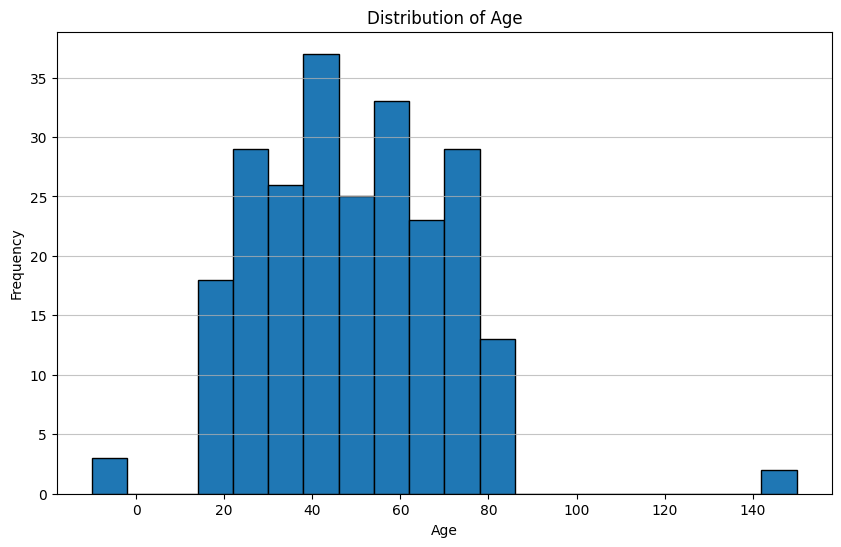

In [261]:
# Plot a histogram of the age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.grid(axis='y', alpha=0.75)
plt.show()

Ignoring the outliers we have a seemingly normal distribution, from here we can mark the outliers as NaN and fill in the NaN values with the median age. We chose median imputation because using the median is more robust than the mean and wont be as affected by remaining edge cases

In [262]:
# Filter out ages less than 18 or greater than 120
df.loc[(df['age'] < 18) | (df['age'] > 120), 'age'] = pd.NA

# Impute all NaN ages with median
df['age'] = df['age'].fillna(df['age'].median()).round()

# once there are no missing values in `age` that column can be set back to an int
#  recall when there are missing values, a numeric col is stored as float.
df['age'] = df['age'].astype('int')


### 5d. filling in missing values for gender

We have 10 missing values for gender, we could impute the data using mean/median/mode but the drawback would be that we could skew our distribution throwing off a machine learning model. Lets look at the distribuition first

In [263]:
# find gender distribution
gender_dist = df['gender'].value_counts(normalize=True)
print(gender_dist)

gender
Female        0.341667
Male          0.329167
Non-binary    0.329167
Name: proportion, dtype: float64


Since the distribution is essentially 33% for each category, a mode imputation would skew the gender distribution too heavily by artificially inflating 'Female'. We could drop the rows here but, since we are trying to preserve as much data as possible we will replace the NaN values with "unknown"  


In [264]:
# In order to add a new category level to a ctegorical column,
# we have to first add the new value to the existing list of values in that category
# Add 'Unknown' as a new category to the 'gender' column
df['gender'] = df['gender'].cat.add_categories('Unknown')

# Fill missing values in the 'gender' column with 'Unknown'
df['gender'] = df['gender'].fillna('Unknown')

# Print the value counts to verify the changes
print(df['gender'].value_counts(dropna=False))

gender
Female        82
Male          79
Non-binary    79
Unknown       10
Name: count, dtype: int64


Why didn't we impute gender using some ML tools? The reason We chose not to impute missing gender values with machine learning because predicting sensitive attributes could introduce bias and create ethical concerns. Instead, we created an "Uknown" category, which preserves all rows and allows the model to learn if missingness itself is a signal of disengagement or churn. This approach avoids false assumptions while still providing potentially valuable insights for business decision-making.


### 5e. filling in missing values for plan type

Imputing missing values for the plan type may be very intuitive because we can assume that there is a relationship between plan_type and Monthly_fee.

Additionally we also suspect that the fees for each type of plan may icrease yearly (in this dataset it is the case). Let us check that.

lets look at the data by plan type and year and see if there is an obvoius range for plan type and monthly_fee that would allow us to impute the missing values


In [265]:
# Group means
print(df.groupby('plan_type')['monthly_fee'].mean())

# Group by year and plan_type, and compute the mean monthly_fee
df.groupby([df['signup_date'].dt.year, 'plan_type'], observed=True)['monthly_fee'].mean()

plan_type
Basic       12.176047
Standard    15.902500
Premium     20.555789
Name: monthly_fee, dtype: float64


/tmp/ipython-input-3316612593.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('plan_type')['monthly_fee'].mean())


signup_date  plan_type
2022         Basic         7.990000
2023         Basic         9.656667
             Standard     12.990000
             Premium      17.704286
2024         Basic        11.923333
             Standard     14.747576
             Premium      19.906667
2025         Basic        13.990000
             Standard     17.990000
             Premium      22.990000
Name: monthly_fee, dtype: float64

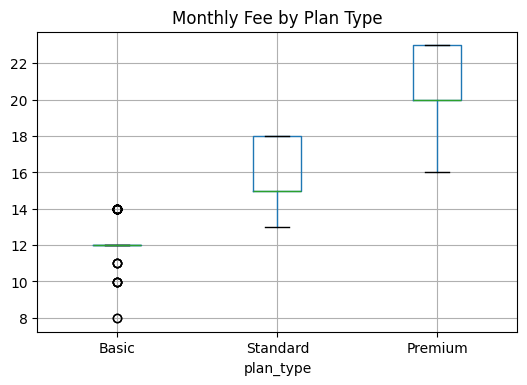

In [266]:
# Boxplot visualization
df.boxplot(column='monthly_fee', by='plan_type', figsize=(6,4))
plt.title("Monthly Fee by Plan Type")
plt.suptitle("")
plt.show()


We can see from above that there is clearly a patter of fees across years and plan type. So what we can do is to impute the missing values by performing group-wise mode imputation for missing values in plan_type where it depends on signup_date's year and monthly_fee


In [267]:
# Perform group-wise mode imputation for missing values in plan_type

# Extract the year from signup_date
df['signup_year'] = df['signup_date'].dt.year

# Group by signup_year and monthly_fee and apply the mode imputation
# We need to handle potential NaN values in the grouping columns if they exist,
# but based on previous checks, signup_year and monthly_fee don't have missing values at this stage.
df['plan_type'] = df.groupby(['signup_year', 'monthly_fee'])['plan_type'].transform(lambda x: x.fillna(x.mode()[0]))

# Drop the temporary 'signup_year' column
df.drop(columns=['signup_year'], inplace=True)

print("Attempted group-wise mode imputation for plan_type based on signup year and monthly fee.")

# Verify if there are any remaining missing plan_type values
print(df['plan_type'].isnull().sum())

Attempted group-wise mode imputation for plan_type based on signup year and monthly fee.
0


## Step 6: Data Validation

We will use a special libraray called pandera to help us do a quick validation of whatever rules we want to enforce.

First, we will install this library into our python enviornment using `pip install`. sometimes libraries are not already avaialble as is the case with pandera.

Pandera checks each column against the rules.
- If all checks pass, it returns the DataFrame unchanged.
- If something fails, it raises a SchemaError (or SchemaErrors if multiple issues).

In [272]:
pip install pandera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 7.5 MB/s eta 0:00:00


In [275]:
import pandera.pandas as pa
from pandera import Column, DataFrameSchema, Check

schema = DataFrameSchema({
    'age' : Column(int, Check.in_range(18,120)),
    'monthly_fee' : Column(float, Check.greater_than_or_equal_to(0)),
    'signup_date': Column(pa.DateTime),
    'gender': Column(str, Check.isin(['Male', 'Female', 'Non-binary','Unknown']))
})
schema.validate(df)

,index,customer_id,signup_date,age,gender,region,monthly_fee,total_streaming_hours,num_devices,plan_type,support_tickets_last_6mo,churned,churned_cat
0,0,972a8469-1641-4f82-8b9d-2434e465e150,2022-01-13,32,Male,East,7.99,169.3,2,Basic,2,0,0
1,1,6fa17735-b572-43d0-8b5c-ea6a41357e8c,2023-09-25,56,Non-binary,North,12.99,73.5,1,Standard,4,0,0
2,2,dca02eec-acda-4acc-9165-e21098543881,2023-09-27,48,Female,East,12.99,133.8,5,Standard,2,1,1
3,3,f5b78cc7-e6b3-4944-8b32-3e357922bac2,2023-10-01,54,Female,East,12.99,178.6,3,Standard,2,0,0
4,4,9132b63e-f162-47e4-a9c3-49e03602f8ac,2023-10-03,61,Male,South,17.99,198.3,1,Premium,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,245,ef8c485b-c07a-40f2-add4-253b50f0fd0a,2025-08-10,77,Non-binary,East,17.99,54.8,2,Standard,2,0,0
246,246,7c441fe7-ab42-40a7-874a-493b3ceddf2d,2025-08-23,34,Male,North,22.99,153.4,3,Premium,2,1,1
247,247,27cb6f2a-8da0-4097-be0f-051b1b66b5a9,2025-09-01,25,Female,East,17.99,31.7,4,Standard,2,0,0
248,248,01d74256-3860-4ab6-96a4-02f23ae8cc93,2025-09-08,25,Female,South,22.99,37.2,2,Premium,1,0,0



## Final Note

In this exercise, we went beyong just identifying data quality issues, but showed you many more ways to clean our data and hgandle misisng values in order to not lose too many values. AT the end of this dfata cleaning and validation process, notice that we have retained all 250 records and added one new column for the target variable as binary categorical. Sometimes it is not possible and we may need to drop rows with quality issues.